# LSTM Bayes

In [2]:
#!pip install --upgrade pip
#!pip install tensorflow
#!pip install statsmodels
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels as sm
import statsmodels.api as sm

In [3]:

def simular_AR1(n, phi, sigma):
    observaciones = np.zeros(n)
    observaciones[0] = np.random.normal(0, sigma/np.sqrt((1-phi**2)))
    for t in range(1, n):
        observaciones[t] = phi * observaciones[t-1] + np.random.normal(0, sigma)
    return observaciones
K = 100000
y_train_phi = np.random.uniform(0.5,0.8,size=K)
y_test_phi = np.random.uniform(0.5,0.8,size=int(K/10))

y_train_sigma = np.random.gamma(shape=2,scale=1,size=K)
y_test_sigma = np.random.gamma(shape=2,scale=1,size=int(K/10))


y_train = np.array([[x, y] for x, y in zip(y_train_phi, y_train_sigma)])
y_test = np.array([[x, y] for x, y in zip(y_test_phi, y_test_sigma)])


m=1500
X_train = np.array([[simular_AR1(m,x,y)] for x, y in zip(y_train_phi, y_train_sigma)])
X_test = np.array([[simular_AR1(m,x,y)] for x, y in zip(y_test_phi, y_test_sigma)])
X_train = np.transpose(X_train, axes=(0, 2, 1))
X_test = np.transpose(X_test, axes=(0, 2, 1))


In [203]:

timesteps, features = m, 1
inputs = tf.keras.layers.Input((timesteps, features))
x = tf.keras.layers.LSTM(32, return_sequences=False)(inputs)
x = tf.keras.layers.Dense(32, activation = "relu")(x)
output1 = tf.keras.layers.Dense(1, activation = "linear", name='output1')(x)
output2 = tf.keras.layers.Dense(1, activation = "linear", name='output2')(x)

model = tf.keras.Model(inputs, [output1, output2])
model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001))


In [204]:
model.fit(X_train, [y_train[:,0],y_train[:,1]] , epochs=5, batch_size=32, shuffle=False,use_multiprocessing=True,workers=4,validation_split=0.2)

Epoch 1/5
2500/2500 [==============================] - 1470s 587ms/step - loss: 1.0537 - output1_loss: 0.0491 - output2_loss: 1.0046 - val_loss: 0.1108 - val_output1_loss: 0.0090 - val_output2_loss: 0.1018
Epoch 2/5
2500/2500 [==============================] - 950s 380ms/step - loss: 0.0722 - output1_loss: 0.0081 - output2_loss: 0.0641 - val_loss: 0.0545 - val_output1_loss: 0.0078 - val_output2_loss: 0.0467
Epoch 3/5
2500/2500 [==============================] - 891s 356ms/step - loss: 0.0440 - output1_loss: 0.0074 - output2_loss: 0.0365 - val_loss: 0.0346 - val_output1_loss: 0.0072 - val_output2_loss: 0.0273
Epoch 4/5
2500/2500 [==============================] - 935s 374ms/step - loss: 0.0360 - output1_loss: 0.0071 - output2_loss: 0.0289 - val_loss: 0.0303 - val_output1_loss: 0.0071 - val_output2_loss: 0.0232
Epoch 5/5
2500/2500 [==============================] - 910s 364ms/step - loss: 0.0326 - output1_loss: 0.0070 - output2_loss: 0.0256 - val_loss: 0.0277 - val_output1_loss: 0.0070 -

In [87]:
#yhat = model.predict(X_test, verbose=1)
#(y_test_phi-yhat[0].reshape(-1)

np.mean(y_train_sigma)
np.mean(y_train_phi)

0.6500182434310813

32/32 [==============================] - 6s 176ms/step


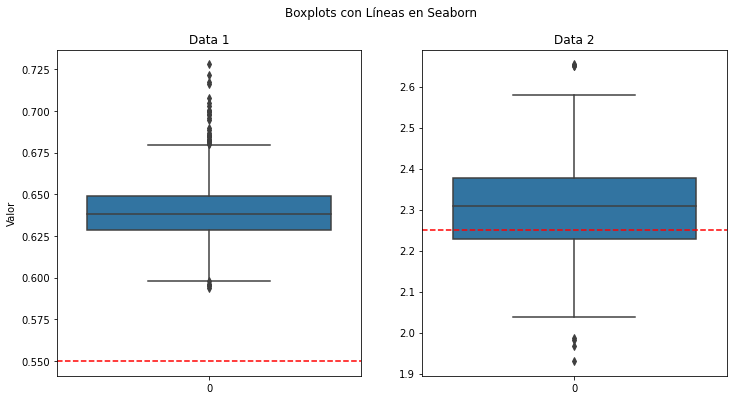

In [205]:

# Valor específico para trazar la línea
line_value1 = 0.55
line_value2 = 2.25

X_val= np.array([[simular_AR1(m,x,y)] for x, y in zip(np.repeat(line_value1,1000), np.repeat(line_value2,1000))])
X_val = np.transpose(X_val, axes=(0, 2, 1))
yval = model.predict(X_val, verbose=1)

# Datos de ejemplo
data1 = yval[0].reshape(-1)
data2 = yval[1].reshape(-1)



fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=False)

# Boxplot para el primer conjunto de datos
sns.boxplot(data=data1, ax=axs[0])
axs[0].axhline(y=line_value1, color='r', linestyle='--')
axs[0].set_title('Data 1')
axs[0].set_ylabel('Valor')

# Boxplot para el segundo conjunto de datos
sns.boxplot(data=data2, ax=axs[1])
axs[1].axhline(y=line_value2, color='r', linestyle='--')
axs[1].set_title('Data 2')

plt.suptitle('Boxplots con Líneas en Seaborn')
plt.show()


Revisemos que se hayan generado bien los datos

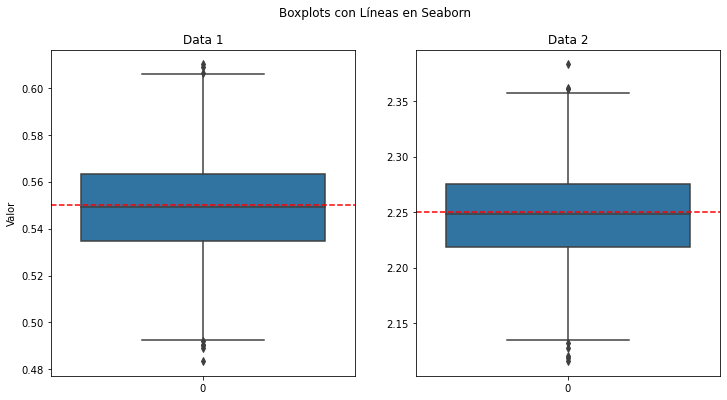

In [80]:
# MLE
# Valor específico para trazar la línea
line_value1 = 0.55
line_value2 = 2.25

X_val= np.array([[simular_AR1(m,x,y)] for x, y in zip(np.repeat(line_value1,1000), np.repeat(line_value2,1000))])
X_val = np.transpose(X_val, axes=(0, 2, 1))
data1 = []
data2 = []
for k in range(len(X_val)):
    mod = sm.tsa.arima.ARIMA(X_val[k], order=(1, 0, 0),trend=[0])
    res = mod.fit()
    data1 =np.append(data1,res.params[0])
    data2 =np.append(data2,res.params[1]**(1/2))


fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=False)

# Boxplot para el primer conjunto de datos
sns.boxplot(data=data1, ax=axs[0])
axs[0].axhline(y=line_value1, color='r', linestyle='--')
axs[0].set_title('Data 1')
axs[0].set_ylabel('Valor')

# Boxplot para el segundo conjunto de datos
sns.boxplot(data=data2, ax=axs[1])
axs[1].axhline(y=line_value2, color='r', linestyle='--')
axs[1].set_title('Data 2')

plt.suptitle('Boxplots con Líneas en Seaborn')
plt.show()


Si se generaron bien

## Regularización y aumento de complejidad

In [176]:

timesteps, features = m, 1
inputs = tf.keras.layers.Input((timesteps, features))
x = tf.keras.layers.LSTM(32, return_sequences=True)(inputs)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.LSTM(32, return_sequences=True)(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.LSTM(32, return_sequences=True)(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.LSTM(32, return_sequences=True)(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.LSTM(32, return_sequences=False)(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Dense(32, activation = "relu")(x)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='loss', mode='min',min_delta=0.001)
output1 = tf.keras.layers.Dense(1, activation = "linear", name='output1')(x)
output2 = tf.keras.layers.Dense(1, activation = "linear", name='output2')(x)

model = tf.keras.Model(inputs, [output1, output2])
model.compile(loss='mse', metrics=['mae','mape'], optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

In [177]:
model.fit(X_train, [y_train[:,0],y_train[:,1]] , epochs=5, batch_size=5, shuffle=False,use_multiprocessing=True,workers=8,validation_split=0.2,callbacks=[early_stopping])

Epoch 1/5
16000/16000 [==============================] - 403s 25ms/step - loss: 0.3030 - output1_loss: 0.0095 - output2_loss: 0.2934 - output1_mae: 0.0807 - output1_mape: 12.7094 - output2_mae: 0.3713 - output2_mape: 29.0518 - val_loss: 0.2173 - val_output1_loss: 0.0078 - val_output2_loss: 0.2096 - val_output1_mae: 0.0759 - val_output1_mape: 11.7252 - val_output2_mae: 0.3110 - val_output2_mape: 21.3524
Epoch 2/5
16000/16000 [==============================] - 406s 25ms/step - loss: 0.2457 - output1_loss: 0.0079 - output2_loss: 0.2378 - output1_mae: 0.0761 - output1_mape: 12.0284 - output2_mae: 0.3366 - output2_mape: 25.0300 - val_loss: 0.2199 - val_output1_loss: 0.0077 - val_output2_loss: 0.2122 - val_output1_mae: 0.0757 - val_output1_mape: 11.6936 - val_output2_mae: 0.3145 - val_output2_mape: 23.1009
Epoch 3/5
16000/16000 [==============================] - 396s 25ms/step - loss: 0.2342 - output1_loss: 0.0078 - output2_loss: 0.2264 - output1_mae: 0.0759 - output1_mape: 11.9895 - output2

32/32 [==============================] - 3s 14ms/step


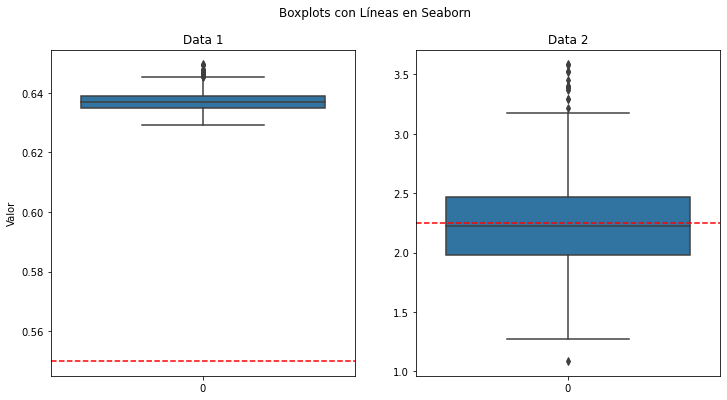

In [178]:

# Valor específico para trazar la línea
line_value1 = 0.55
line_value2 = 2.25

X_val= np.array([[simular_AR1(m,x,y)] for x, y in zip(np.repeat(line_value1,1000), np.repeat(line_value2,1000))])
X_val = np.transpose(X_val, axes=(0, 2, 1))
yval = model.predict(X_val, verbose=1)

# Datos de ejemplo
data1 = yval[0].reshape(-1)
data2 = yval[1].reshape(-1)



fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=False)

# Boxplot para el primer conjunto de datos
sns.boxplot(data=data1, ax=axs[0])
axs[0].axhline(y=line_value1, color='r', linestyle='--')
axs[0].set_title('Data 1')
axs[0].set_ylabel('Valor')

# Boxplot para el segundo conjunto de datos
sns.boxplot(data=data2, ax=axs[1])
axs[1].axhline(y=line_value2, color='r', linestyle='--')
axs[1].set_title('Data 2')

plt.suptitle('Boxplots con Líneas en Seaborn')
plt.show()


## Diferencias

Entrenemos usando las diferencias en ves de la serie pura

In [62]:
m=15
X_train_dif = np.array([[np.diff(simular_AR1(m,x,y))] for x, y in zip(y_train_phi, y_train_sigma)])
X_test_dif = np.array([[np.diff(simular_AR1(m,x,y))] for x, y in zip(y_test_phi, y_test_sigma)])
X_train_dif = np.transpose(X_train_dif, axes=(0, 2, 1))
X_test_dif = np.transpose(X_test_dif, axes=(0, 2, 1))

In [64]:
timesteps, features = len(X_train_dif[0]), 1
inputs = tf.keras.layers.Input((timesteps, features))
x = tf.keras.layers.LSTM(32, return_sequences=False)(inputs)
x = tf.keras.layers.Dropout(0.2)(x)
#x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=True))(x)
#x = tf.keras.layers.Dropout(0.2)(x)
#x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=True))(x)
#x = tf.keras.layers.Dropout(0.2)(x)
#x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=True))(x)
#x = tf.keras.layers.Dropout(0.2)(x)
#x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=False))(x)
#x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Dense(32, activation = "relu")(x)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='loss', mode='min',min_delta=0.001)
output1 = tf.keras.layers.Dense(1, activation = "linear", name='output1')(x)
output2 = tf.keras.layers.Dense(1, activation = "linear", name='output2')(x)

model = tf.keras.Model(inputs, [output1, output2])
model.compile(loss='mse', metrics=['mae','mape'], optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

In [65]:
model.fit(X_train_dif, [y_train[:,0],y_train[:,1]] , epochs=5, batch_size=5, shuffle=False,use_multiprocessing=True,workers=8,validation_split=0.2)

Epoch 1/5
16000/16000 [==============================] - 95s 6ms/step - loss: 0.2765 - output1_loss: 0.0099 - output2_loss: 0.2666 - output1_mae: 0.0806 - output1_mape: 12.6958 - output2_mae: 0.3468 - output2_mape: 24.6599 - val_loss: 0.2744 - val_output1_loss: 0.0082 - val_output2_loss: 0.2662 - val_output1_mae: 0.0772 - val_output1_mape: 11.8192 - val_output2_mae: 0.3422 - val_output2_mape: 30.2765
Epoch 2/5
16000/16000 [==============================] - 80s 5ms/step - loss: 0.2365 - output1_loss: 0.0078 - output2_loss: 0.2287 - output1_mae: 0.0758 - output1_mape: 11.9768 - output2_mae: 0.3271 - output2_mape: 22.3104 - val_loss: 0.2415 - val_output1_loss: 0.0077 - val_output2_loss: 0.2337 - val_output1_mae: 0.0757 - val_output1_mape: 11.7245 - val_output2_mae: 0.3396 - val_output2_mape: 34.5916
Epoch 3/5
16000/16000 [==============================] - 80s 5ms/step - loss: 0.2317 - output1_loss: 0.0077 - output2_loss: 0.2240 - output1_mae: 0.0757 - output1_mape: 11.9525 - output2_mae: 

32/32 [==============================] - 1s 4ms/step


Text(0.5, 0.98, 'Boxplots')

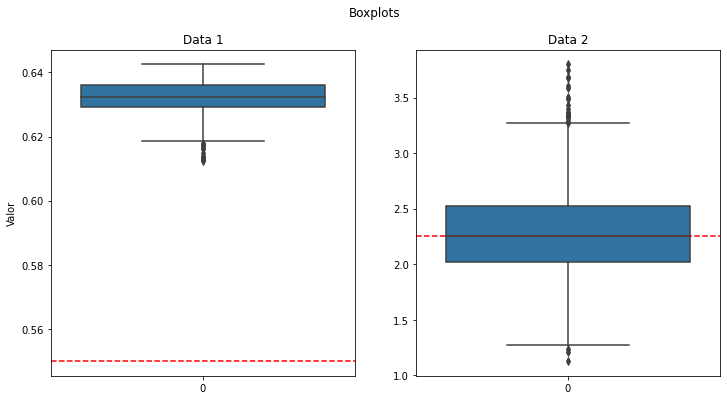

In [67]:

# Valor específico para trazar la línea
line_value1 = 0.55
line_value2 = 2.25

X_val= np.array([[np.diff(simular_AR1(m,x,y))] for x, y in zip(np.repeat(line_value1,1000), np.repeat(line_value2,1000))])
X_val = np.transpose(X_val, axes=(0, 2, 1))
yval = model.predict(X_val, verbose=1)

# Datos de ejemplo
data1 = yval[0].reshape(-1)
data2 = yval[1].reshape(-1)



fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=False)

# Boxplot para el primer conjunto de datos
sns.boxplot(data=data1, ax=axs[0])
axs[0].axhline(y=line_value1, color='r', linestyle='--')
axs[0].set_title('Data 1')
axs[0].set_ylabel('Valor')

# Boxplot para el segundo conjunto de datos
sns.boxplot(data=data2, ax=axs[1])
axs[1].axhline(y=line_value2, color='r', linestyle='--')
axs[1].set_title('Data 2')

plt.suptitle('Boxplots')

In [68]:
timesteps, features = len(X_train_dif[0]), 1
inputs = tf.keras.layers.Input((timesteps, features))
x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=True))(inputs)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=True))(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=True))(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=True))(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=False))(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Dense(32, activation = "relu")(x)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='loss', mode='min',min_delta=0.001)
output1 = tf.keras.layers.Dense(1, activation = "linear", name='output1')(x)
output2 = tf.keras.layers.Dense(1, activation = "linear", name='output2')(x)

model = tf.keras.Model(inputs, [output1, output2])
model.compile(loss='mse', metrics=['mae','mape'], optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

In [69]:
model.fit(X_train_dif, [y_train[:,0],y_train[:,1]] , epochs=5, batch_size=5, shuffle=False,use_multiprocessing=True,workers=8,validation_split=0.2)

Epoch 1/5
16000/16000 [==============================] - 425s 26ms/step - loss: 0.2791 - output1_loss: 0.0095 - output2_loss: 0.2696 - output1_mae: 0.0803 - output1_mape: 12.6509 - output2_mae: 0.3535 - output2_mape: 25.4676 - val_loss: 0.2582 - val_output1_loss: 0.0083 - val_output2_loss: 0.2499 - val_output1_mae: 0.0778 - val_output1_mape: 11.8321 - val_output2_mae: 0.3282 - val_output2_mape: 22.2245
Epoch 2/5
16000/16000 [==============================] - 439s 27ms/step - loss: 0.2403 - output1_loss: 0.0080 - output2_loss: 0.2324 - output1_mae: 0.0764 - output1_mape: 12.0589 - output2_mae: 0.3293 - output2_mape: 21.8854 - val_loss: 0.2273 - val_output1_loss: 0.0081 - val_output2_loss: 0.2193 - val_output1_mae: 0.0770 - val_output1_mape: 11.7652 - val_output2_mae: 0.3153 - val_output2_mape: 23.5356
Epoch 3/5
16000/16000 [==============================] - 431s 27ms/step - loss: 0.2322 - output1_loss: 0.0077 - output2_loss: 0.2244 - output1_mae: 0.0758 - output1_mape: 11.9586 - output2

32/32 [==============================] - 4s 12ms/step


Text(0.5, 0.98, 'Boxplots')

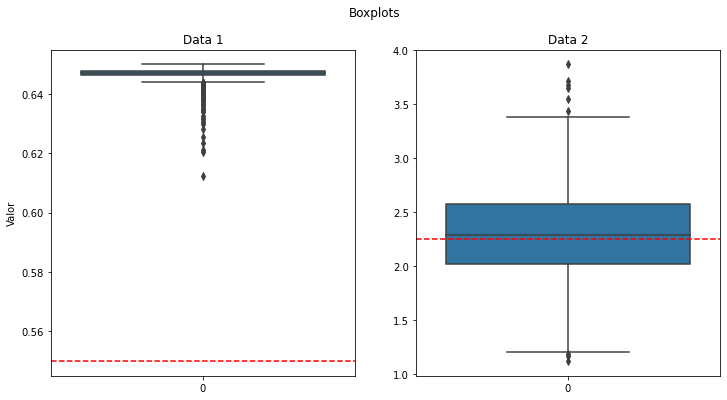

In [70]:

# Valor específico para trazar la línea
line_value1 = 0.55
line_value2 = 2.25

X_val= np.array([[np.diff(simular_AR1(m,x,y))] for x, y in zip(np.repeat(line_value1,1000), np.repeat(line_value2,1000))])
X_val = np.transpose(X_val, axes=(0, 2, 1))
yval = model.predict(X_val, verbose=1)

# Datos de ejemplo
data1 = yval[0].reshape(-1)
data2 = yval[1].reshape(-1)



fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=False)

# Boxplot para el primer conjunto de datos
sns.boxplot(data=data1, ax=axs[0])
axs[0].axhline(y=line_value1, color='r', linestyle='--')
axs[0].set_title('Data 1')
axs[0].set_ylabel('Valor')

# Boxplot para el segundo conjunto de datos
sns.boxplot(data=data2, ax=axs[1])
axs[1].axhline(y=line_value2, color='r', linestyle='--')
axs[1].set_title('Data 2')

plt.suptitle('Boxplots')

## Varianza constante

In [177]:
K = 100000
y_train_phi = np.random.uniform(0.5,0.8,size=K)
y_test_phi = np.random.uniform(0.5,0.8,size=int(K/10))

y_train_sigma = np.repeat(1,K)
y_test_sigma = np.repeat(1,int(K/10))


y_train = np.array([[x, y] for x, y in zip(y_train_phi, y_train_sigma)])
y_test = np.array([[x, y] for x, y in zip(y_test_phi, y_test_sigma)])


m=15
X_train = np.array([[simular_AR1(m,x,y)] for x, y in zip(y_train_phi, y_train_sigma)])
X_test = np.array([[simular_AR1(m,x,y)] for x, y in zip(y_test_phi, y_test_sigma)])
X_train = np.transpose(X_train, axes=(0, 2, 1))
X_test = np.transpose(X_test, axes=(0, 2, 1))


In [182]:
timesteps, features = len(X_train[0]), 1
inputs = tf.keras.layers.Input((timesteps, features))
x = tf.keras.layers.LSTM(32, return_sequences=False)(inputs)
x = tf.keras.layers.Dropout(0.2)(x)
#x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=True))(x)
#x = tf.keras.layers.Dropout(0.2)(x)
#x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=True))(x)
#x = tf.keras.layers.Dropout(0.2)(x)
#x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=True))(x)
#x = tf.keras.layers.Dropout(0.2)(x)
#x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=False))(x)
#x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Dense(32, activation = "relu")(x)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='loss', mode='min',min_delta=0.001)
output1 = tf.keras.layers.Dense(1, activation = "linear", name='output1')(x)
output2 = tf.keras.layers.Dense(1, activation = "linear", name='output2')(x)

model = tf.keras.Model(inputs, [output1])
model.compile(loss='mse', metrics=['mae','mape'], optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

In [185]:
model.fit(X_train, [y_train[:,0]] , epochs=5, batch_size=5, shuffle=False,use_multiprocessing=True,workers=8,validation_split=0.2)

Epoch 1/5
16000/16000 [==============================] - 90s 6ms/step - loss: 0.0068 - mae: 0.0700 - mape: 11.0544 - val_loss: 0.0067 - val_mae: 0.0692 - val_mape: 11.1960
Epoch 2/5
16000/16000 [==============================] - 78s 5ms/step - loss: 0.0066 - mae: 0.0689 - mape: 10.8835 - val_loss: 0.0066 - val_mae: 0.0684 - val_mape: 11.0385
Epoch 3/5
16000/16000 [==============================] - 77s 5ms/step - loss: 0.0066 - mae: 0.0686 - mape: 10.8345 - val_loss: 0.0066 - val_mae: 0.0681 - val_mape: 10.9717
Epoch 4/5
16000/16000 [==============================] - 77s 5ms/step - loss: 0.0066 - mae: 0.0685 - mape: 10.8116 - val_loss: 0.0065 - val_mae: 0.0680 - val_mape: 10.9280
Epoch 5/5
16000/16000 [==============================] - 95s 6ms/step - loss: 0.0065 - mae: 0.0683 - mape: 10.7919 - val_loss: 0.0065 - val_mae: 0.0680 - val_mape: 10.9013


32/32 [==============================] - 1s 4ms/step


Text(0, 0.5, 'Valor')

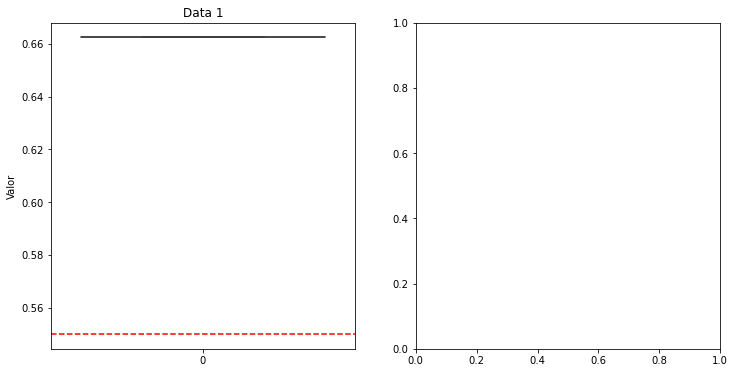

In [187]:

# Valor específico para trazar la línea
line_value1 = 0.55
line_value2 = 1

X_val= np.array([[simular_AR1(m,x,y)] for x, y in zip(np.repeat(line_value1,1000), np.repeat(line_value2,1000))])
X_val = np.transpose(X_val, axes=(0, 2, 1))
yval = model.predict(X_val, verbose=1)

# Datos de ejemplo
data1 = yval[0].reshape(-1)



fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=False)

# Boxplot para el primer conjunto de datos
sns.boxplot(data=data1, ax=axs[0])
axs[0].axhline(y=line_value1, color='r', linestyle='--')
axs[0].set_title('Data 1')
axs[0].set_ylabel('Valor')